<a href="https://colab.research.google.com/github/taissa-arruda/prog_estat/blob/main/Resolu%C3%A7%C3%A3o_labs/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercício 1**

In [ ]:
import numpy as np

In [ ]:
X = 1
p = .1

bern = np.random.uniform() < p

while bern != 1:
  bern = np.random.uniform() < p
  X += 1

In [ ]:
M = 1000
amostra = []

for i in range(M):
  X = 1
  p = .1

  bern = np.random.uniform() < p

  while bern != 1:
    bern = np.random.uniform() < p
    X += 1
  amostra.append(X)

print(amostra)

[18, 4, 7, 2, 2, 25, 4, 5, 10, 17, 25, 16, 11, 4, 1, 19, 4, 8, 16, 1, 13, 7, 7, 5, 2, 28, 27, 17, 32, 3, 5, 6, 2, 37, 15, 22, 10, 6, 3, 4, 2, 10, 34, 17, 5, 7, 9, 1, 32, 5, 15, 1, 22, 12, 10, 10, 1, 12, 9, 12, 2, 19, 14, 11, 1, 12, 4, 12, 3, 14, 3, 1, 4, 5, 6, 13, 4, 1, 9, 7, 12, 2, 28, 8, 50, 5, 3, 3, 7, 21, 8, 21, 7, 17, 4, 41, 6, 2, 15, 1, 22, 1, 10, 16, 9, 3, 14, 8, 11, 13, 13, 50, 6, 25, 5, 17, 26, 3, 3, 11, 2, 1, 5, 13, 28, 1, 3, 4, 22, 1, 7, 3, 7, 10, 4, 15, 29, 2, 6, 13, 5, 6, 6, 1, 2, 36, 11, 7, 1, 1, 6, 4, 5, 13, 5, 39, 10, 22, 5, 12, 6, 15, 7, 13, 15, 4, 3, 3, 6, 5, 16, 2, 3, 15, 21, 2, 2, 2, 3, 5, 1, 13, 2, 4, 15, 7, 1, 5, 4, 9, 5, 1, 5, 2, 4, 15, 1, 1, 14, 9, 7, 9, 4, 3, 15, 3, 5, 30, 6, 2, 19, 13, 16, 12, 7, 4, 5, 9, 3, 1, 8, 12, 1, 22, 4, 40, 2, 1, 6, 2, 4, 12, 1, 4, 6, 7, 9, 12, 3, 23, 4, 17, 7, 3, 8, 3, 11, 7, 1, 2, 28, 4, 9, 1, 4, 8, 2, 7, 6, 6, 2, 1, 1, 6, 36, 5, 27, 18, 16, 5, 14, 4, 2, 16, 3, 4, 5, 3, 23, 11, 16, 1, 8, 16, 4, 5, 24, 24, 7, 23, 1, 3, 10, 3, 8, 3, 2,

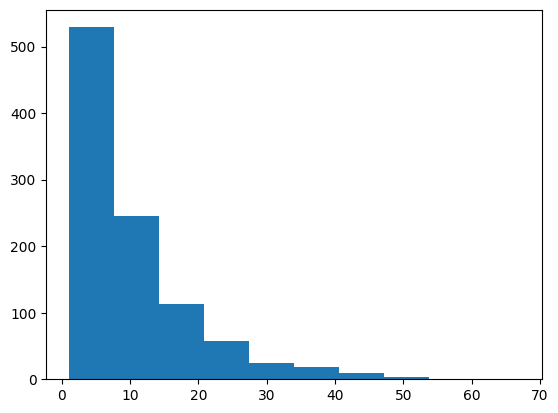

In [ ]:
import matplotlib.pyplot as plt

plt.hist(amostra)
plt.show()

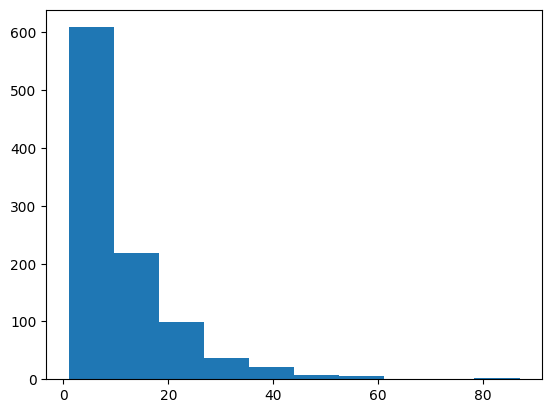

In [ ]:
amostra_numpy = np.random.geometric(p, M)

plt.hist(amostra_numpy)
plt.show()

**Exercício 2**

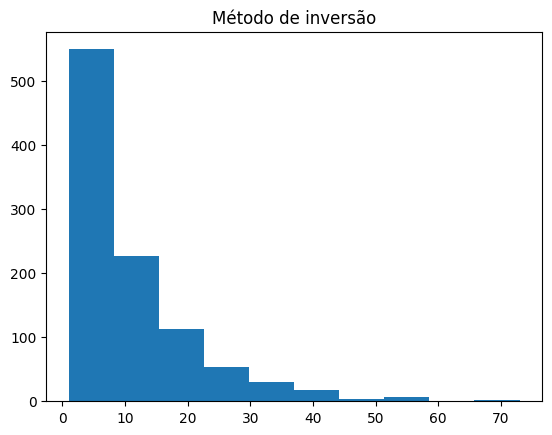

In [ ]:
def geometrica_inversao(p):
    u = np.random.uniform()
    x = np.log(1 - u) / np.log(1 - p)
    return np.ceil(x)

M = 1000
amostra_inversao = [geometrica_inversao(p) for _ in range(M)]

plt.hist(amostra_inversao)
plt.title('Método de inversão')
plt.show()

In [ ]:
def geometrica_ingenuo(p):
    X = 1
    bern = np.random.uniform() < p
    while bern != 1:
        bern = np.random.uniform() < p
        X += 1
    return X

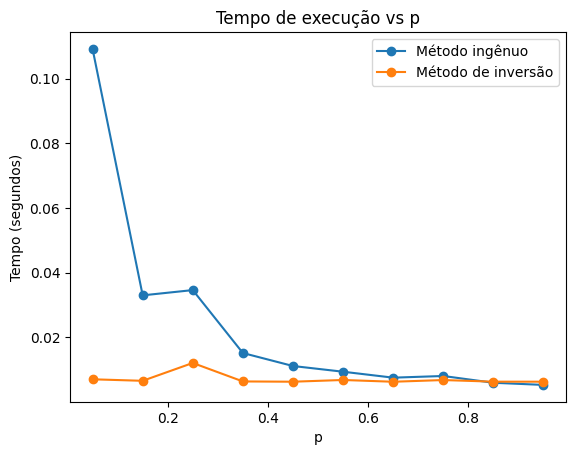

In [ ]:
import time

valores_p = np.linspace(0.05, 0.95, 10)
M = 1000

tempos_ingenuo = []
tempos_inversao = []

for p in valores_p:
    inicio = time.time()
    amostra = [geometrica_ingenuo(p) for _ in range(M)]
    tempos_ingenuo.append(time.time() - inicio)

    inicio = time.time()
    amostra = [geometrica_inversao(p) for _ in range(M)]
    tempos_inversao.append(time.time() - inicio)

plt.plot(valores_p, tempos_ingenuo, marker='o', label='Método ingênuo')
plt.plot(valores_p, tempos_inversao, marker='o', label='Método de inversão')
plt.xlabel('p')
plt.ylabel('Tempo (segundos)')
plt.title('Tempo de execução vs p')
plt.legend()
plt.show()

**Exercício 3**

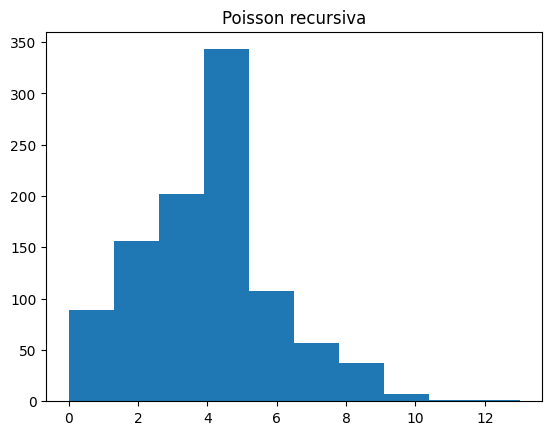

In [ ]:
def poisson_recursiva(lam):
    U = np.random.uniform()

    i = 0
    pi = np.exp(-lam)
    F = pi

    while U > F:
        pi = (lam / (i + 1)) * pi
        i += 1
        F += pi

    return i

M = 1000
lam = 4
amostra_poisson = [poisson_recursiva(lam) for _ in range(M)]

plt.hist(amostra_poisson)
plt.title('Poisson recursiva')
plt.show()

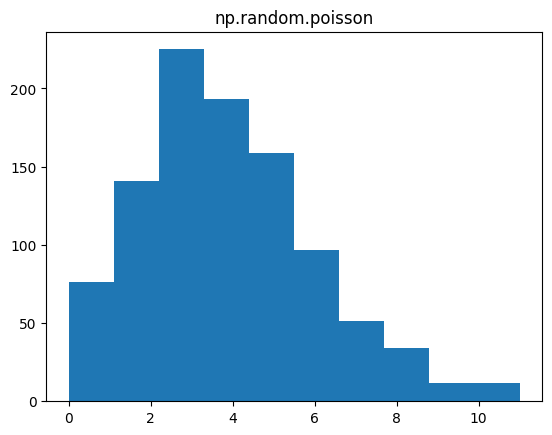

In [ ]:
#versao numpy

amostra_numpy_poisson = np.random.poisson(lam, M)
plt.hist(amostra_numpy_poisson)
plt.title('np.random.poisson')
plt.show()